# Technical Evaluation: How does memory consumption of VeriGym's datastructures for explicit models compare to that of other tools?

We compare the memory consumption of `VeriGym`'s `TransitionFunction` and `FrameworkExplicitEnv` with the memory consumption of `stormpy.SparseTransitionMatrix` and `stormpy.storage.SparseMdp`.
Further, we compare the sparse transition function representations from `VeriGym` and `stormpy` with non-sparse representation using `numpy`-arrays.

The goal is to 1) see whether/how much memory overhead `VeriGym` introduces over `stormpy`, and 2) compare the extend to which our sparse representation reduces memory consumption as opposed to non-sparse representations.

We use four PRISM MDP benchmarks from the Quantitative Verification Benchmark Set [(qcomp)](https://qcomp.org/benchmarks/) at different sizes. 
Specifically, we consider two grid-worlds (Pacman and Resource Gathering), and two internet protocols (Consensus and Zeroconf) to cover models with different structures. 
Models have states spaces $S$ with $400 \leq |S| \leq 1.000.000$.

## Imports and Helpers

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import sys
import json

from verigym.frameworks.stormpy.stormpy_utils import load_stormpy_model
from verigym.environments.frameworkexplicitenv import FrameworkExplicitEnv



In [2]:
def recursive_sizeof(obj, seen=None):
    if seen is None:
        seen = set()
    obj_id = id(obj)

    if obj_id in seen:
        return 0

    seen.add(obj_id)
    size = sys.getsizeof(obj)

    if isinstance(obj, dict):
        size += sum(
            recursive_sizeof(key, seen) + 
            recursive_sizeof(value, seen)
            for key, value in obj.items()
        )

    elif isinstance(obj, (list, tuple, set, frozenset)):
        size += sum(recursive_sizeof(item, seen) for item in obj)
    else:
        # Attributes stored in __dict__
        if hasattr(obj, "__dict__"):
            size += recursive_sizeof(obj.__dict__, seen)
        # Attributes stored using __slots__
        slots = getattr(type(obj), "__slots__", ())
        if isinstance(slots, str):
            slots = (slots,)

        for slot in slots:
            if slot in ("__dict__", "__weakref__"):
                continue
            try:
                value = getattr(obj, slot)
            except AttributeError:
                continue

            size += recursive_sizeof(value, seen)
    return size

In [3]:
def compute_transition_matrix_size(mdp):
    # Stormpy transition matrix is CSA sparse matrix, can compare like so
    transitions_bit = mdp.nr_transitions * 64
    choice_bits = mdp.nr_choices * 64 * 2
    state_bits = mdp.nr_states * 64

    bits = transitions_bit + choice_bits + state_bits
    return bits

def transition_function_to_np(n_states, n_actions, t_dict):
    non_sparse = np.zeros((n_states, n_actions, n_states))

    for s in t_dict.keys():
        for a in t_dict[s].keys():
            for s_prime in t_dict[s][a].keys():
                non_sparse[s, a, s_prime] = t_dict[s][a][s_prime]

    return non_sparse

In [4]:
in_folder = "tech_eval_files/"

benchmarks = [
    {
        "name": "Consensus.4",
        "file": in_folder + "consensus.4.v1.prism",
        "constants": ["K=2", "K=4"]
    }, {
        "name": "Pacman",
        "file": in_folder + "pacman.v2.nm",
        "constants": ["MAXSTEPS=5"],
    }, {
        "name": "Resource Gathering",
        "file": in_folder + "resource-gathering.v2.pm",
        "constants": ["B=200,GOLD_TO_COLLECT=15,GEM_TO_COLLECT=15",
                      "B=400,GOLD_TO_COLLECT=30,GEM_TO_COLLECT=30"],
    }, {
        "name": "Zeroconf",
        "file": in_folder + "zeroconf.v1.prism",
        "constants": ["N=20,K=2,reset=true", "N=20,K=4,reset=true",
                      "N=20,K=2,reset=false", "N=20,K=4,reset=false"]
    }, 
]

## Evaluation

In [5]:
transition_function_sizes = {}
env_or_mdp_sizes = {}

for benchmark in benchmarks:
    transition_function_sizes[benchmark["name"]] = {}
    env_or_mdp_sizes[benchmark["name"]] = {}
    for i, constants in enumerate(benchmark["constants"]):
        mdp = load_stormpy_model(
            benchmark["file"], constants=constants
        )
        env = FrameworkExplicitEnv.from_stormpy(mdp)
        t_as_np = transition_function_to_np(env.nr_states, env.nr_actions, env.transition_function.T_dict)

        res = subprocess.run(
            [
                "./tech_eval_files/memory_eval.sh",
                benchmark["file"],
                constants,
                "stormpy"
            ],
            capture_output=True,
            text=True,
            check=True
        )
        mdp_out = json.loads(res.stdout)

        res = subprocess.run(
            [
                "./tech_eval_files/memory_eval.sh",
                benchmark["file"],
                constants,
                "env"
            ],
            capture_output=True,
            text=True,
            check=True
        )
        env_out = json.loads(res.stdout)
        transition_function_sizes[benchmark["name"]][constants] = {
            "stormpy": compute_transition_matrix_size(mdp),
            "verigym": recursive_sizeof(env.transition_function),
            "numpy": recursive_sizeof(t_as_np),
            "n_states": mdp.nr_states,
            "n_transitions": mdp.nr_transitions,
        }
        transition_function_sizes[benchmark["name"]][constants]["numpy"] = recursive_sizeof(t_as_np)
        env_or_mdp_sizes[benchmark["name"]][constants] = {
            "verigym,sizeoff": recursive_sizeof(env),
            "verigym,process": env_out["change"],
            "verigym,process,w.build": env_out["change_mdp"],
            "stormpy,process": mdp_out["change"],
            "n_states": mdp.nr_states,
            "n_transitions": mdp.nr_transitions,
        }


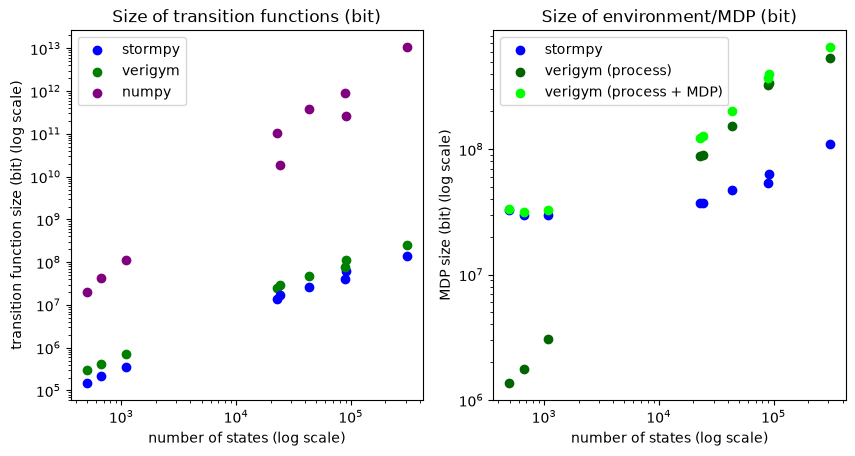

In [ ]:
fig, axs = plt.subplots(1, 2)
fig.set_figwidth(10)

axs[0].set_title("Size of transition functions (bit)")
for i, (tb, tvariants) in enumerate(transition_function_sizes.items()):
    for j, (tc, data) in enumerate(tvariants.items()):
        axs[0].scatter(data["n_states"], data["stormpy"], 
                       label="stormpy" if i == 0 and j == 0 else "", 
                       color="blue")
        axs[0].scatter(data["n_states"], data["verigym"], 
                       label="verigym" if i == 0 and j == 0 else "", 
                       color="green" )
        if "numpy" in data.keys():
            axs[0].scatter(data["n_states"], data["numpy"], 
                        label="numpy" if i == 0 and j == 0 else "", 
                        color="purple")

axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].set_xlabel("number of states (log scale)")
axs[0].set_ylabel("transition function size (bit) (log scale)")
axs[0].legend()

axs[1].set_title("Size of environment/MDP (bit)")
for i, (eb, evariants) in enumerate(env_or_mdp_sizes.items()):
    for j, (ec, data) in enumerate(evariants.items()):
        axs[1].scatter(data["n_states"], data["stormpy,process"], 
                       label="stormpy" if i == 0 and j == 0 else "", 
                       color="blue")
        axs[1].scatter(data["n_states"], data["verigym,process"], 
                       label="verigym (process)" if i == 0 and j == 0 else "", 
                       color="darkgreen")
        axs[1].scatter(data["n_states"], data["verigym,process,w.build"], 
                       label="verigym (process + MDP)" if i == 0 and j == 0 else "", 
                       color="lime")

axs[1].set_yscale("log") 
axs[1].set_xscale("log")
axs[1].legend()
axs[1].set_xlabel("number of states (log scale)")
axs[1].set_ylabel("MDP size (bit) (log scale)")

plt.show()

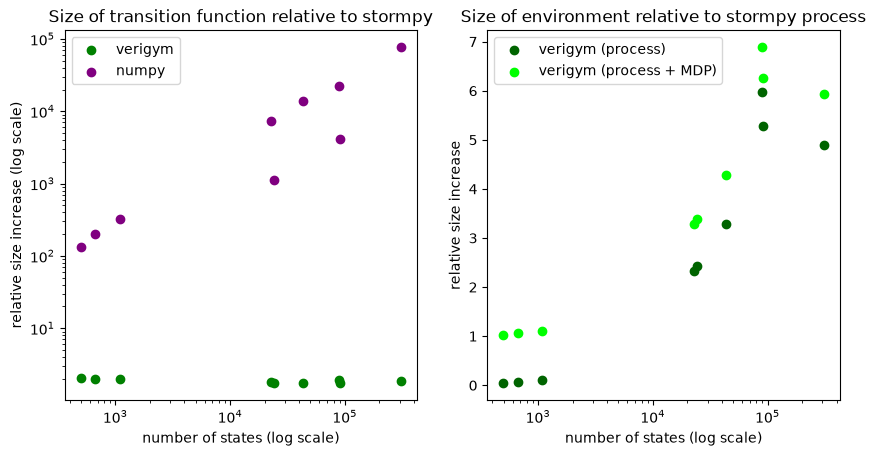

In [11]:
fig, axs = plt.subplots(1, 2)
fig.set_figwidth(10)

axs[0].set_title("Size of transition function relative to stormpy")
for i, (tb, tvariants) in enumerate(transition_function_sizes.items()):
    for j, (tc, data) in enumerate(tvariants.items()):
        axs[0].scatter(data["n_states"], data["verigym"]/data["stormpy"], 
                       label="verigym" if i == 0 and j == 0 else "", 
                       color="green" )
        if "numpy" in data.keys():
            axs[0].scatter(data["n_states"], data["numpy"]/data["stormpy"], 
                        label="numpy" if i == 0 and j == 0 else "", 
                        color="purple")

axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].set_xlabel("number of states (log scale)")
axs[0].set_ylabel("relative size increase (log scale)")
axs[0].legend()

axs[1].set_title("Size of environment relative to stormpy process")
for i, (eb, evariants) in enumerate(env_or_mdp_sizes.items()):
    for j, (ec, data) in enumerate(evariants.items()):
        axs[1].scatter(data["n_states"], data["verigym,process"]/data["stormpy,process"], 
                       label="verigym (process)" if i == 0 and j == 0 else "", 
                       color="darkgreen")
        axs[1].scatter(data["n_states"], data["verigym,process,w.build"]/data["stormpy,process"], 
                       label="verigym (process + MDP)" if i == 0 and j == 0 else "", 
                       color="lime")

axs[1].legend()
axs[1].set_xscale("log")
axs[1].set_xlabel("number of states (log scale)")
axs[1].set_ylabel("relative size increase")

plt.show()

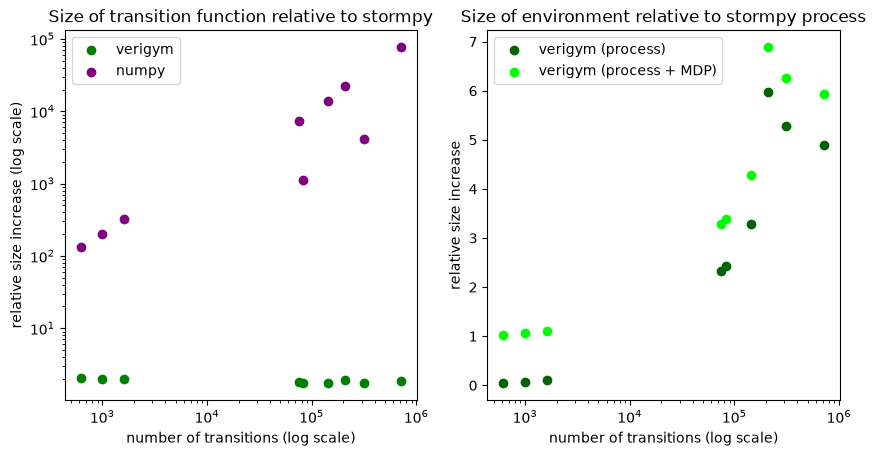

In [8]:
fig, axs = plt.subplots(1, 2)
fig.set_figwidth(10)

axs[0].set_title("Size of transition function relative to stormpy")
for i, (tb, tvariants) in enumerate(transition_function_sizes.items()):
    for j, (tc, data) in enumerate(tvariants.items()):
        axs[0].scatter(data["n_transitions"], data["verigym"]/data["stormpy"], 
                       label="verigym" if i == 0 and j == 0 else "", 
                       color="green" )
        if "numpy" in data.keys():
            axs[0].scatter(data["n_transitions"], data["numpy"]/data["stormpy"], 
                        label="numpy" if i == 0 and j == 0 else "", 
                        color="purple")

axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].set_xlabel("number of transitions (log scale)")
axs[0].set_ylabel("relative size increase (log scale)")
axs[0].legend()

axs[1].set_title("Size of environment relative to stormpy process")
for i, (eb, evariants) in enumerate(env_or_mdp_sizes.items()):
    for j, (ec, data) in enumerate(evariants.items()):
        axs[1].scatter(data["n_transitions"], data["verigym,process"]/data["stormpy,process"], 
                       label="verigym (process)" if i == 0 and j == 0 else "", 
                       color="darkgreen")
        axs[1].scatter(data["n_transitions"], data["verigym,process,w.build"]/data["stormpy,process"], 
                       label="verigym (process + MDP)" if i == 0 and j == 0 else "", 
                       color="lime")

axs[1].legend()
axs[1].set_xscale("log")
axs[1].set_xlabel("number of transitions (log scale)")
axs[1].set_ylabel("relative size increase")
plt.show()